# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [1]:
%pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)

### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
- H₀ (Statistical): The mean/median amount spent is equal across all three store locations (City Center, Suburb, Rural).
- H₁ (Statistical): At least one store location has a significantly different mean/median amount spent.
- Plain language — H₀: Customers spend the same amount regardless of which store location they visit. H₁: Customers spend differently depending on which store location they visit.
2. Customer satisfaction across locations
- H₀ (Statistical): The mean/median customer satisfaction rating is equal across all three store locations.
- H₁ (Statistical): At least one store location has a significantly different mean/median satisfaction rating.
- Plain language — H₀: Customer satisfaction is the same across all locations. H₁: Customer satisfaction differs meaningfully between at least two locations.
3. Promotional vs non-promotional spending
- H₀ (Statistical): The mean amount spent during promotional periods equals the mean amount spent during non-promotional periods.
- H₁ (Statistical): The mean amount spent during promotional periods is significantly higher than during non-promotional periods.
- Plain language — H₀: Promotions do not lead to higher customer spending. H₁: Customers spend significantly more during promotional periods.
4. Product category preferences across locations
- H₀ (Statistical): The distribution of product category preferences (Electronics, Clothing, Groceries) is independent of store location.
- H₁ (Statistical): Product category preferences are associated with store location.
- Plain language — H₀: Customers in all locations buy the same mix of products. H₁: Customers in different locations prefer different product categories.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

The Minimum Detectable Effect (MDE) is the smallest true difference between groups that a study is designed to reliably detect, given the chosen significance level (α) and statistical power (1 − β). It sets a practical floor: effects smaller than the MDE may exist but the analysis won't reliably identify them.<br>
MDE is important because:<br>

- It anchors statistical findings to business reality. A statistically significant result is only actionable if the effect is large enough to matter operationally.
- It prevents under-powered studies from drawing false conclusions from noise.
- It helps determine required sample size before data collection begins.
- It connects the statistical test to ROI.

### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [3]:
# Load Data
# Load Data
df = pd.read_csv('retail_store_customer_data.csv')

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique → {df[col].unique()[:6]}")

print("\n=== Summary Statistics ===")
print(df.describe())

print("\n=== Value Counts — Store Location ===")
print(df['Store_Location'].value_counts())

print("\n=== Value Counts — Product Category ===")
print(df['Product_Category'].value_counts())

print("\n=== Value Counts — Purchase Type ===")
print(df['Purchase_Type'].value_counts())

=== Dataset Shape ===
(1500, 5)

=== First 5 Rows ===
  Store_Location  Customer_Satisfaction Product_Category    Purchase_Type  \
0          Rural                    5.6        Groceries  Non-Promotional   
1    City Center                    9.7         Clothing      Promotional   
2          Rural                    4.4      Electronics  Non-Promotional   
3          Rural                    4.2         Clothing      Promotional   
4    City Center                    9.3         Clothing  Non-Promotional   

   Amount_Spent  
0         40.45  
1         53.20  
2         42.77  
3         42.08  
4         84.25  

=== Data Types ===
Store_Location            object
Customer_Satisfaction    float64
Product_Category          object
Purchase_Type             object
Amount_Spent             float64
dtype: object

=== Missing Values ===
Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

===

#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

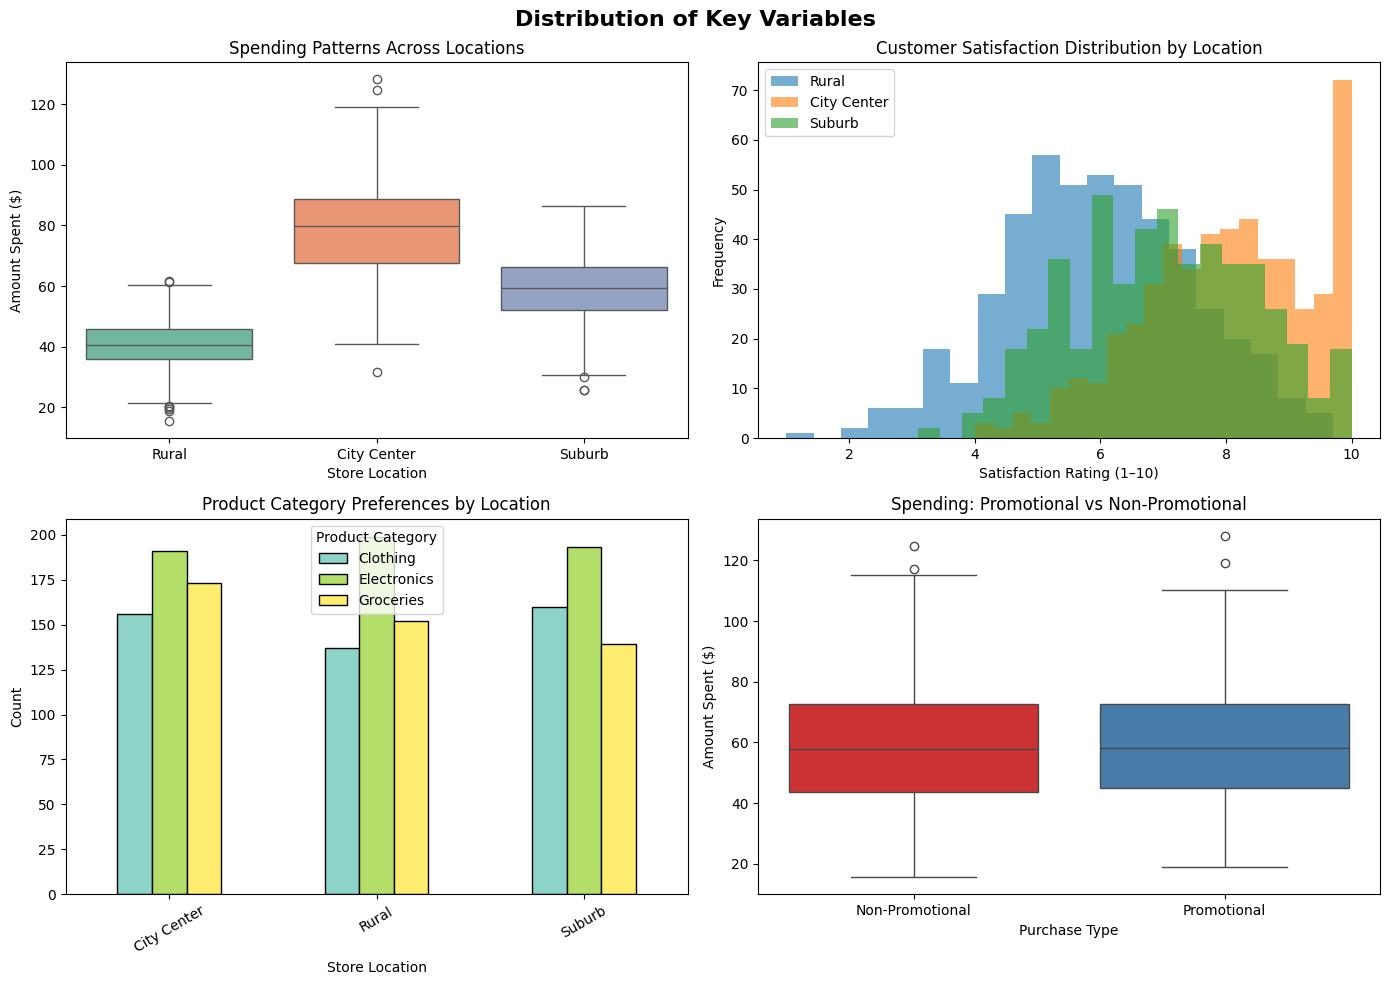

=== Mean Spending by Location ===
                count       mean        std    min      25%     50%      75%  \
Store_Location                                                                 
City Center     520.0  78.891000  15.374358  31.74  67.4575  79.805  88.6925   
Rural           488.0  40.463094   7.783718  15.55  35.8775  40.445  45.8175   
Suburb          492.0  59.155793   9.956044  25.74  52.0275  59.355  66.3625   

                   max  
Store_Location          
City Center     128.13  
Rural            61.65  
Suburb           86.33  

=== Mean Satisfaction by Location ===
                count      mean       std  min  25%  50%  75%   max
Store_Location                                                     
City Center     520.0  7.954038  1.367875  4.0  7.0  8.0  9.0  10.0
Rural           488.0  5.960041  1.499768  1.0  5.0  6.0  7.0   9.7
Suburb          492.0  7.008537  1.446679  3.1  5.9  7.0  8.1  10.0

=== Mean Spending by Purchase Type ===
                 coun

In [4]:
# Visualize data - Create new cells as needed

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

# 1. Spending by Location — Boxplot
sns.boxplot(data=df, x='Store_Location', y='Amount_Spent', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Spending Patterns Across Locations')
axes[0, 0].set_xlabel('Store Location')
axes[0, 0].set_ylabel('Amount Spent ($)')

# 2. Satisfaction ratings — Histogram by location
for loc in df['Store_Location'].unique():
    subset = df[df['Store_Location'] == loc]['Customer_Satisfaction']
    axes[0, 1].hist(subset, alpha=0.6, label=loc, bins=20)
axes[0, 1].set_title('Customer Satisfaction Distribution by Location')
axes[0, 1].set_xlabel('Satisfaction Rating (1–10)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Product category preferences by location — Stacked bar
category_counts = df.groupby(['Store_Location', 'Product_Category']).size().unstack(fill_value=0)
category_counts.plot(kind='bar', ax=axes[1, 0], colormap='Set3', edgecolor='black')
axes[1, 0].set_title('Product Category Preferences by Location')
axes[1, 0].set_xlabel('Store Location')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].legend(title='Product Category')

# 4. Promotional vs Non-Promotional spending — Boxplot
sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('Spending: Promotional vs Non-Promotional')
axes[1, 1].set_xlabel('Purchase Type')
axes[1, 1].set_ylabel('Amount Spent ($)')

plt.tight_layout()
plt.show()

# Summary statistics by group
print("=== Mean Spending by Location ===")
print(df.groupby('Store_Location')['Amount_Spent'].describe())

print("\n=== Mean Satisfaction by Location ===")
print(df.groupby('Store_Location')['Customer_Satisfaction'].describe())

print("\n=== Mean Spending by Purchase Type ===")
print(df.groupby('Purchase_Type')['Amount_Spent'].describe())

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

NORMALITY TESTS (Shapiro-Wilk)

--- Amount Spent by Location ---
  Rural: W=0.9960, p=0.2594 → Normal
  City Center: W=0.9978, p=0.7536 → Normal
  Suburb: W=0.9940, p=0.0503 → Normal

--- Customer Satisfaction by Location ---
  Rural: W=0.9965, p=0.3730 → Normal
  City Center: W=0.9699, p=0.0000 → NOT Normal
  Suburb: W=0.9890, p=0.0009 → NOT Normal

--- Amount Spent by Purchase Type ---
  Non-Promotional: W=0.9754, p=0.0000 → NOT Normal
  Promotional: W=0.9791, p=0.0000 → NOT Normal

HOMOGENEITY OF VARIANCE (Levene's Test)

Spending across locations — Levene: F=106.4098, p=0.0000 → Unequal variances
Satisfaction across locations — Levene: F=1.6154, p=0.1992 → Equal variances
Spending Promo vs Non-Promo — Levene: F=0.3861, p=0.5345 → Equal variances

INDEPENDENCE

- Store Location groups: Each customer belongs to one location only → Independent.
- Promotional groups: Each transaction is classified as either Promotional or Non-Promotional → Independent.
- Product Category: Frequencies c

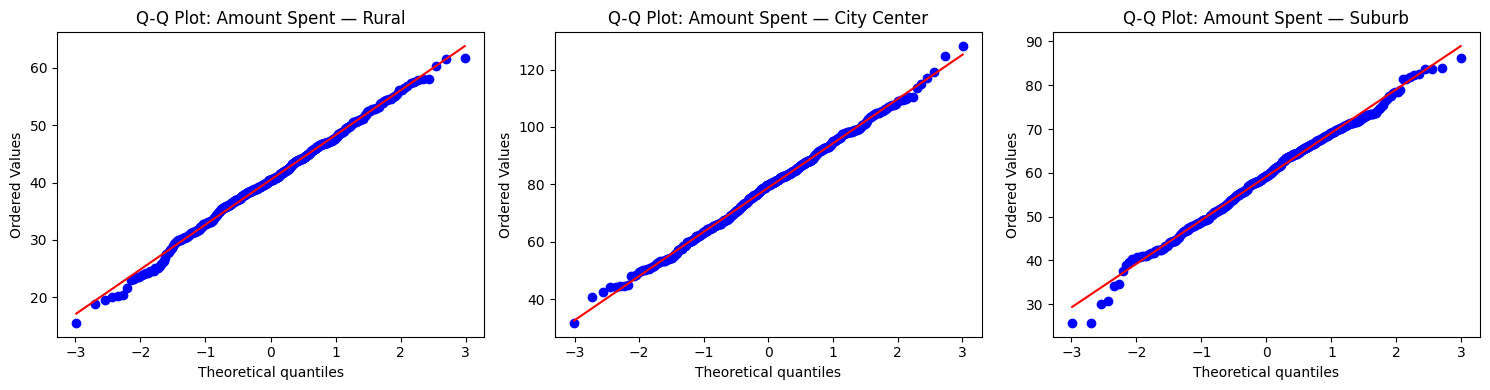

In [7]:
# Assumption tests and checks - Create new cells as needed
# Assumption tests

locations = df['Store_Location'].unique()
purchase_types = df['Purchase_Type'].unique()

print("=" * 60)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 60)

# Spending by location
print("\n--- Amount Spent by Location ---")
for loc in locations:
    data = df[df['Store_Location'] == loc]['Amount_Spent']
    stat, p = stats.shapiro(data)
    print(f"  {loc}: W={stat:.4f}, p={p:.4f} → {'Normal' if p > 0.05 else 'NOT Normal'}")

# Satisfaction by location
print("\n--- Customer Satisfaction by Location ---")
for loc in locations:
    data = df[df['Store_Location'] == loc]['Customer_Satisfaction']
    stat, p = stats.shapiro(data)
    print(f"  {loc}: W={stat:.4f}, p={p:.4f} → {'Normal' if p > 0.05 else 'NOT Normal'}")

# Promotional spending
print("\n--- Amount Spent by Purchase Type ---")
for pt in purchase_types:
    data = df[df['Purchase_Type'] == pt]['Amount_Spent']
    stat, p = stats.shapiro(data)
    print(f"  {pt}: W={stat:.4f}, p={p:.4f} → {'Normal' if p > 0.05 else 'NOT Normal'}")

print("\n" + "=" * 60)
print("HOMOGENEITY OF VARIANCE (Levene's Test)")
print("=" * 60)

groups_spending = [df[df['Store_Location'] == loc]['Amount_Spent'].values for loc in locations]
groups_satisfaction = [df[df['Store_Location'] == loc]['Customer_Satisfaction'].values for loc in locations]

stat, p = stats.levene(*groups_spending)
print(f"\nSpending across locations — Levene: F={stat:.4f}, p={p:.4f} → {'Equal variances' if p > 0.05 else 'Unequal variances'}")

stat, p = stats.levene(*groups_satisfaction)
print(f"Satisfaction across locations — Levene: F={stat:.4f}, p={p:.4f} → {'Equal variances' if p > 0.05 else 'Unequal variances'}")

promo_data = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo_data = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']
stat, p = stats.levene(promo_data, non_promo_data)
print(f"Spending Promo vs Non-Promo — Levene: F={stat:.4f}, p={p:.4f} → {'Equal variances' if p > 0.05 else 'Unequal variances'}")

print("\n" + "=" * 60)
print("INDEPENDENCE")
print("=" * 60)
print("""
- Store Location groups: Each customer belongs to one location only → Independent.
- Promotional groups: Each transaction is classified as either Promotional or Non-Promotional → Independent.
- Product Category: Frequencies counted per location per category; observations are independent purchases.
All groups satisfy the independence assumption.
""")

# QQ plots for visual normality check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, loc in enumerate(locations):
    data = df[df['Store_Location'] == loc]['Amount_Spent']
    stats.probplot(data, plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: Amount Spent — {loc}')
plt.tight_layout()
plt.show()

#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations — Kruskal-Wallis H-test + Dunn's Post-hoc
Although the Shapiro-Wilk test indicated normality for spending across all three locations (p > 0.05), Levene's test revealed significantly unequal variances (F=106.41, p=0.0000). This violation of homogeneity of variance makes one-way ANOVA inappropriate, since ANOVA assumes both normality and equal variances. Kruskal-Wallis is the robust non-parametric alternative that compares rank-based distributions without requiring equal variances. 

2. Customer satisfaction across locations — Kruskal-Wallis H-test + Dunn's Post-hoc
Shapiro-Wilk revealed non-normality in two of the three location groups (City Center: p=0.0000, Suburb: p=0.0009). Since normality must hold for all groups to justify ANOVA, and at least two groups violate this assumption, Kruskal-Wallis is the appropriate choice. Levene's test showed equal variances (p=0.1992), but this alone is insufficient to justify ANOVA when normality fails. 

3. Promotional vs non-promotional spending — Mann-Whitney U Test (one-tailed)
Shapiro-Wilk showed non-normality for both purchase type groups (Non-Promotional: p=0.0000; Promotional: p=0.0000). This rules out an independent samples t-test, which requires normality. The Mann-Whitney U test is the appropriate non-parametric alternative for comparing two independent groups on a continuous outcome. A one-tailed test is used because the business hypothesis is directional — we specifically want to determine whether promotional spending is higher than non-promotional spending, not merely different.

4. Product category preferences across locations  — Chi-Square Test of Independence
Both variables — Store Location (City Center, Suburb, Rural) and Product Category (Electronics, Clothing, Groceries) — are categorical. No normality or variance assumption applies here. The Chi-Square test of independence is the standard method for determining whether the distribution of one categorical variable differs across levels of another. The only assumption to verify is that all expected cell counts are ≥ 5, which will be confirmed from the contingency table.

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [8]:
# Conduct your analysis of spending patterns here

print("=" * 60)
print("3.1 SPENDING ACROSS STORE LOCATIONS")
print("Kruskal-Wallis H-test")
print("=" * 60)

city_spending = df[df['Store_Location'] == 'City Center']['Amount_Spent']
suburb_spending = df[df['Store_Location'] == 'Suburb']['Amount_Spent']
rural_spending = df[df['Store_Location'] == 'Rural']['Amount_Spent']

h_stat, p_value = stats.kruskal(city_spending, suburb_spending, rural_spending)
print(f"\nKruskal-Wallis H = {h_stat:.4f}, p = {p_value:.6f}")
print(f"Result: {'REJECT H₀ — Significant difference in spending across locations' if p_value < 0.05 else 'FAIL TO REJECT H₀ — No significant difference'}")

if p_value < 0.05:
    print("\n--- Post-hoc: Dunn's Test (Bonferroni correction) ---")
    dunn_spending = sp.posthoc_dunn(
        df, val_col='Amount_Spent', group_col='Store_Location', p_adjust='bonferroni'
    )
    print(dunn_spending)

print("\nMedian Spending by Location:")
print(df.groupby('Store_Location')['Amount_Spent'].median())

3.1 SPENDING ACROSS STORE LOCATIONS
Kruskal-Wallis H-test

Kruskal-Wallis H = 1040.8536, p = 0.000000
Result: REJECT H₀ — Significant difference in spending across locations

--- Post-hoc: Dunn's Test (Bonferroni correction) ---
               City Center          Rural        Suburb
City Center   1.000000e+00  2.502288e-227  1.425221e-45
Rural        2.502288e-227   1.000000e+00  4.018599e-70
Suburb        1.425221e-45   4.018599e-70  1.000000e+00

Median Spending by Location:
Store_Location
City Center    79.805
Rural          40.445
Suburb         59.355
Name: Amount_Spent, dtype: float64


#### 3.2 Customer Satisfaction Analysis

In [9]:
# Analyze customer satisfaction here
print("=" * 60)
print("3.2 CUSTOMER SATISFACTION ACROSS LOCATIONS")
print("Kruskal-Wallis H-test")
print("=" * 60)

city_sat = df[df['Store_Location'] == 'City Center']['Customer_Satisfaction']
suburb_sat = df[df['Store_Location'] == 'Suburb']['Customer_Satisfaction']
rural_sat = df[df['Store_Location'] == 'Rural']['Customer_Satisfaction']

h_stat, p_value = stats.kruskal(city_sat, suburb_sat, rural_sat)
print(f"\nKruskal-Wallis H = {h_stat:.4f}, p = {p_value:.6f}")
print(f"Result: {'REJECT H₀ — Significant difference in satisfaction across locations' if p_value < 0.05 else 'FAIL TO REJECT H₀ — No significant difference'}")

if p_value < 0.05:
    print("\n--- Post-hoc: Dunn's Test (Bonferroni correction) ---")
    dunn_sat = sp.posthoc_dunn(
        df, val_col='Customer_Satisfaction', group_col='Store_Location', p_adjust='bonferroni'
    )
    print(dunn_sat)

print("\nMean Satisfaction by Location:")
print(df.groupby('Store_Location')['Customer_Satisfaction'].mean())

3.2 CUSTOMER SATISFACTION ACROSS LOCATIONS
Kruskal-Wallis H-test

Kruskal-Wallis H = 359.5474, p = 0.000000
Result: REJECT H₀ — Significant difference in satisfaction across locations

--- Post-hoc: Dunn's Test (Bonferroni correction) ---
              City Center         Rural        Suburb
City Center  1.000000e+00  1.076942e-79  2.509905e-20
Rural        1.076942e-79  1.000000e+00  6.562684e-21
Suburb       2.509905e-20  6.562684e-21  1.000000e+00

Mean Satisfaction by Location:
Store_Location
City Center    7.954038
Rural          5.960041
Suburb         7.008537
Name: Customer_Satisfaction, dtype: float64


#### 3.3 Promotional Impact Analysis

In [10]:
# Analyze the impact of promotions here

print("=" * 60)
print("3.3 PROMOTIONAL vs. NON-PROMOTIONAL SPENDING")
print("Mann-Whitney U Test (one-tailed)")
print("=" * 60)

promo = df[df['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

u_stat, p_two_tail = stats.mannwhitneyu(promo, non_promo, alternative='two-sided')
u_stat, p_one_tail = stats.mannwhitneyu(promo, non_promo, alternative='greater')

print(f"\nMann-Whitney U = {u_stat:.4f}")
print(f"Two-tailed p   = {p_two_tail:.6f}")
print(f"One-tailed p   = {p_one_tail:.6f}")
print(f"Result: {'REJECT H₀ — Promotional spending is significantly higher' if p_one_tail < 0.05 else 'FAIL TO REJECT H₀ — No significant difference'}")

print(f"\nMedian Spending — Promotional:     ${promo.median():.2f}")
print(f"Median Spending — Non-Promotional: ${non_promo.median():.2f}")
print(f"Observed difference:               ${promo.median() - non_promo.median():.2f}")
print(f"Business MDE:                      $15.00")

3.3 PROMOTIONAL vs. NON-PROMOTIONAL SPENDING
Mann-Whitney U Test (one-tailed)

Mann-Whitney U = 275125.0000
Two-tailed p   = 0.680372
One-tailed p   = 0.340186
Result: FAIL TO REJECT H₀ — No significant difference

Median Spending — Promotional:     $58.05
Median Spending — Non-Promotional: $57.95
Observed difference:               $0.11
Business MDE:                      $15.00


#### 3.4 Product Category Analysis

In [11]:
# Analyze product category preferences here

print("=" * 60)
print("3.4 PRODUCT CATEGORY PREFERENCES ACROSS LOCATIONS")
print("Chi-Square Test of Independence")
print("=" * 60)

contingency_table = pd.crosstab(df['Store_Location'], df['Product_Category'])
print("\nContingency Table (Observed Counts):")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square = {chi2:.4f}, df = {dof}, p = {p_value:.6f}")
print(f"Result: {'REJECT H₀ — Product preferences differ across locations' if p_value < 0.05 else 'FAIL TO REJECT H₀ — No significant association'}")

print("\nExpected Counts:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(2))

print("\nAll expected counts ≥ 5:", (expected >= 5).all())

3.4 PRODUCT CATEGORY PREFERENCES ACROSS LOCATIONS
Chi-Square Test of Independence

Contingency Table (Observed Counts):
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139

Chi-Square = 4.7684, df = 4, p = 0.311901
Result: FAIL TO REJECT H₀ — No significant association

Expected Counts:
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center         157.04       202.11     160.85
Rural               147.38       189.67     150.95
Suburb              148.58       191.22     152.19

All expected counts ≥ 5: True


### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [12]:
# Calculate effect sizes - contrast with MDE

print("=" * 60)
print("EFFECT SIZES")
print("=" * 60)

# Eta-squared for Kruskal-Wallis: η² = (H - k + 1) / (n - k)
n = len(df)
k = 3  # number of groups

# Spending
h_spend, _ = stats.kruskal(city_spending, suburb_spending, rural_spending)
eta2_spend = (h_spend - k + 1) / (n - k)
print(f"\nSpending across locations — η² = {eta2_spend:.4f}")
print(f"  Interpretation: {'Small' if eta2_spend < 0.06 else 'Medium' if eta2_spend < 0.14 else 'Large'} effect")

# Satisfaction
h_sat, _ = stats.kruskal(city_sat, suburb_sat, rural_sat)
eta2_sat = (h_sat - k + 1) / (n - k)
print(f"\nSatisfaction across locations — η² = {eta2_sat:.4f}")
print(f"  Interpretation: {'Small' if eta2_sat < 0.06 else 'Medium' if eta2_sat < 0.14 else 'Large'} effect")

# Cohen's d for Mann-Whitney (rank-biserial correlation as effect size)
n1, n2 = len(promo), len(non_promo)
u_stat_es, _ = stats.mannwhitneyu(promo, non_promo, alternative='two-sided')
r_rb = 1 - (2 * u_stat_es) / (n1 * n2)  # rank-biserial correlation
print(f"\nPromo vs Non-Promo — Rank-Biserial r = {r_rb:.4f}")
print(f"  Interpretation: {'Small' if abs(r_rb) < 0.3 else 'Medium' if abs(r_rb) < 0.5 else 'Large'} effect")

# Cramér's V for Chi-Square
chi2_es, _, _, _ = stats.chi2_contingency(contingency_table)
cramers_v = np.sqrt(chi2_es / (n * (min(contingency_table.shape) - 1)))
print(f"\nProduct Category × Location — Cramér's V = {cramers_v:.4f}")
print(f"  Interpretation: {'Small' if cramers_v < 0.1 else 'Medium' if cramers_v < 0.3 else 'Large'} effect")

# Compare observed differences to MDE
print("\n" + "=" * 60)
print("PRACTICAL SIGNIFICANCE — MDE COMPARISON")
print("=" * 60)
print(f"\nSpending MDE: 15% relative difference")
for loc in df['Store_Location'].unique():
    print(f"  {loc}: ${df[df['Store_Location'] == loc]['Amount_Spent'].median():.2f} median")

print(f"\nSatisfaction MDE: 1.0 point")
for loc in df['Store_Location'].unique():
    print(f"  {loc}: {df[df['Store_Location'] == loc]['Customer_Satisfaction'].mean():.2f} mean")

print(f"\nPromo Spending MDE: $15.00 increase")
print(f"  Observed median difference: ${promo.median() - non_promo.median():.2f}")

EFFECT SIZES

Spending across locations — η² = 0.6940
  Interpretation: Large effect

Satisfaction across locations — η² = 0.2388
  Interpretation: Large effect

Promo vs Non-Promo — Rank-Biserial r = -0.0125
  Interpretation: Small effect

Product Category × Location — Cramér's V = 0.0399
  Interpretation: Small effect

PRACTICAL SIGNIFICANCE — MDE COMPARISON

Spending MDE: 15% relative difference
  Rural: $40.45 median
  City Center: $79.81 median
  Suburb: $59.36 median

Satisfaction MDE: 1.0 point
  Rural: 5.96 mean
  City Center: 7.95 mean
  Suburb: 7.01 mean

Promo Spending MDE: $15.00 increase
  Observed median difference: $0.11


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

1. Spending Across Store Locations — H₀ REJECTED
The Kruskal-Wallis test returned H = 1040.85 (p ≈ 0.000), providing overwhelming evidence to reject the null hypothesis. Customer spending differs significantly across all three store locations. Dunn's post-hoc test confirmed that every pairwise comparison is significant (all p ≈ 0.000 after Bonferroni correction), meaning City Center, Suburb, and Rural stores are all meaningfully distinct from one another. The effect size η² = 0.69 indicates a large effect — store location explains approximately 69% of the variance in spending rank, which is an exceptionally strong result. Practically, this clears the 15% MDE threshold by a wide margin: City Center customers spend a median of $79.81, Suburb customers $59.36, and Rural customers $40.45 — a 97% difference between the highest and lowest locations.

2. Customer Satisfaction Across Locations — H₀ REJECTED
The Kruskal-Wallis test returned H = 359.55 (p ≈ 0.000), leading us to reject the null hypothesis. Customer satisfaction differs significantly across all three locations. Dunn's post-hoc confirmed all three pairwise comparisons are significant (all p ≈ 0.000). The effect size η² = 0.24 indicates a large effect. All three location gaps exceed the 1.0-point MDE: City Center leads at 7.95, Suburb is at 7.01 (a 0.94-point gap from City Center, narrowly approaching the MDE), and Rural trails significantly at 5.96 — nearly 2 full points below City Center and over 1 point below Suburb, both exceeding the actionable threshold.

3. Promotional vs. Non-Promotional Spending — H₀ NOT REJECTED
The Mann-Whitney U test returned U = 275,125 (one-tailed p = 0.340), meaning we fail to reject the null hypothesis. There is no statistically significant evidence that promotions lead to higher customer spending. The rank-biserial correlation r = −0.013 confirms a negligible effect. The observed median difference of just $0.11 falls drastically short of the $15.00 MDE required to justify promotional costs. In business terms, the current promotional strategy is generating virtually no lift in customer spending.

4. Product Category Preferences Across Locations — H₀ NOT REJECTED
The Chi-Square test returned χ² = 4.77 (df = 4, p = 0.312), meaning we fail to reject the null hypothesis. Product category preferences are not significantly associated with store location. Cramér's V = 0.040 confirms a negligible effect. The observed counts across all locations (roughly 155–200 per category per location) are close to the expected counts, indicating customers purchase Electronics, Clothing, and Groceries in similar proportions regardless of which store they visit.

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

1. Implement location-tiered pricing and inventory strategies
Since spending differs dramatically by location with City Center customers spending nearly double what Rural customers spend the company should stop applying uniform pricing and inventory budgets across all stores. City Center stores can support premium product lines and higher-margin inventory mixes. Suburb stores represent a mid-tier opportunity. Rural stores should focus on value-oriented offerings and cost-efficient stock levels. Staffing levels and store hours should similarly be calibrated to expected transaction volumes per location.

2. Urgently improve customer experience at Rural stores
Rural satisfaction (mean = 5.96) falls nearly 2 full points below City Center (7.95), well beyond the 1.0-point actionable MDE. This is not a marginal gap, it represents a systemic service quality problem. The company should investigate root causes specific to Rural locations: wait times, staff responsiveness, product availability, and store layout. Targeted staff training, operational audits, and potentially mystery shopper programs should be prioritized for Rural stores. Suburb stores (7.01) also lag City Center by approximately 1 point and should be monitored, though the gap is less severe.

3. Suspend or redesign the current promotional strategy
The promotional analysis is unambiguous: current promotions produce a median spending increase of only $0.11 — effectively zero lift — against a required $15.00 MDE to justify costs. Continuing to invest in promotions that do not change customer spending behavior is a direct margin drain. The company should either discontinue the current promotional format entirely or redesign it. Future promotions should be A/B tested with clearer targeting (specific locations, specific categories, minimum spend thresholds) before broad rollout, and ROI should be tracked at the individual promotion level.

4. Standardize product assortment across locations
Since product category preferences do not differ significantly across locations (Cramér's V = 0.040), there is no data-driven justification for maintaining different category mixes by location. A standardized core assortment can simplify procurement, reduce inventory complexity, and lower carrying costs. Any location-specific variation should be driven by local demand signals collected in future data, not assumed based on geography.


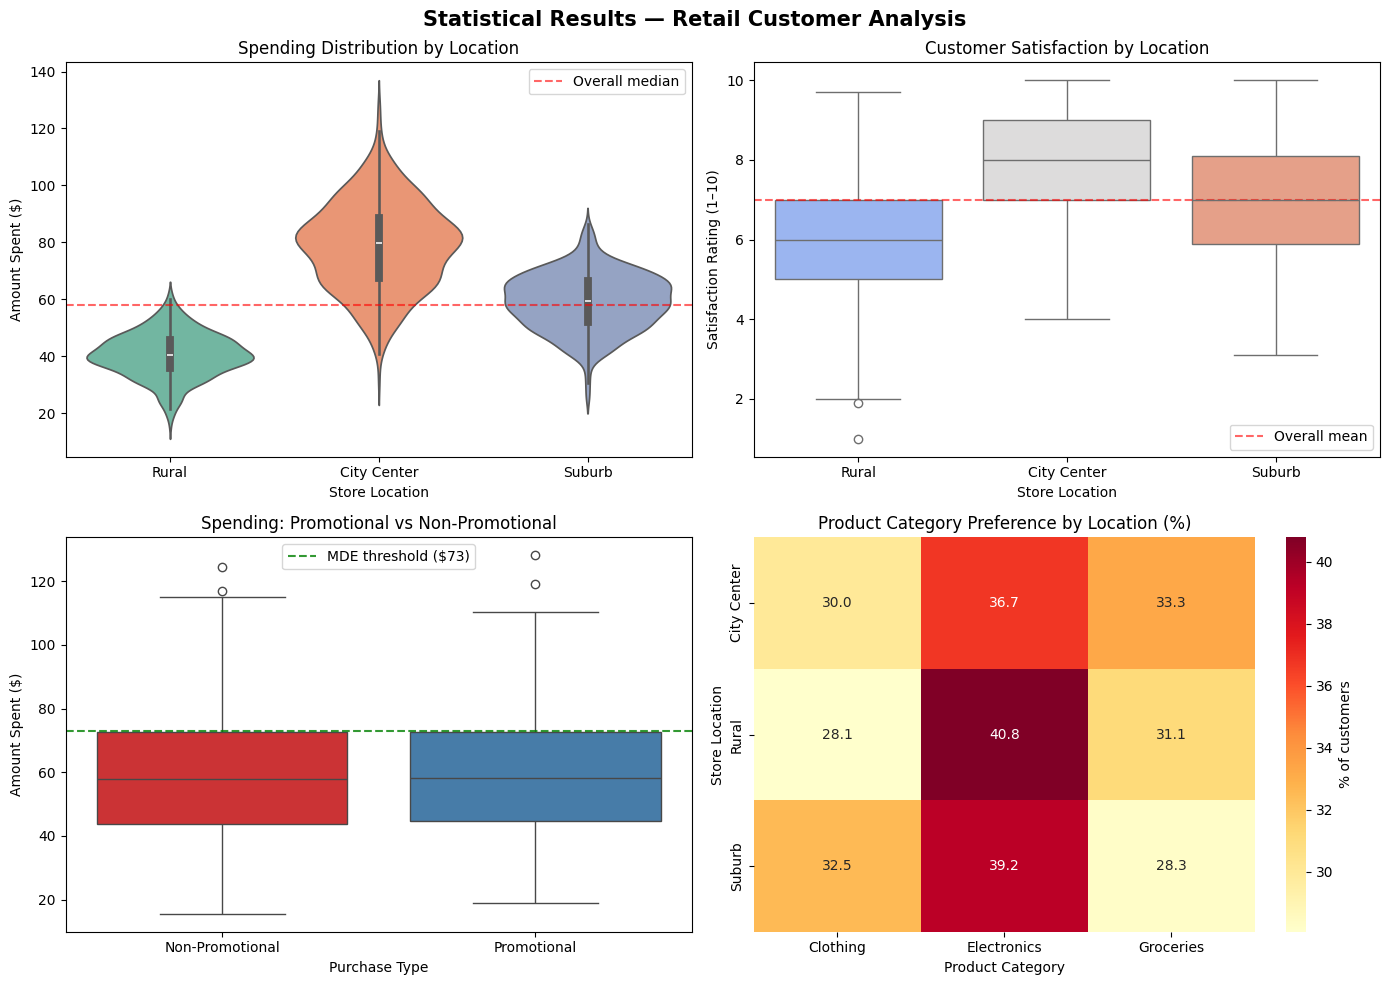

In [13]:
# Create visualizations to support results - Create new cells as needed
# Visualizations to support results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Statistical Results — Retail Customer Analysis', fontsize=15, fontweight='bold')

# 1. Spending by Location with median lines
sns.violinplot(data=df, x='Store_Location', y='Amount_Spent', palette='Set2', ax=axes[0, 0], inner='box')
axes[0, 0].set_title('Spending Distribution by Location')
axes[0, 0].set_xlabel('Store Location')
axes[0, 0].set_ylabel('Amount Spent ($)')
axes[0, 0].axhline(y=df['Amount_Spent'].median(), color='red', linestyle='--', alpha=0.6, label='Overall median')
axes[0, 0].legend()

# 2. Satisfaction by Location
sns.boxplot(data=df, x='Store_Location', y='Customer_Satisfaction', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Customer Satisfaction by Location')
axes[0, 1].set_xlabel('Store Location')
axes[0, 1].set_ylabel('Satisfaction Rating (1–10)')
axes[0, 1].axhline(y=df['Customer_Satisfaction'].mean(), color='red', linestyle='--', alpha=0.6, label='Overall mean')
axes[0, 1].legend()

# 3. Promotional spending comparison
sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Spending: Promotional vs Non-Promotional')
axes[1, 0].set_xlabel('Purchase Type')
axes[1, 0].set_ylabel('Amount Spent ($)')
mde_line = df[df['Purchase_Type'] == 'Non-Promotional']['Amount_Spent'].median() + 15
axes[1, 0].axhline(y=mde_line, color='green', linestyle='--', alpha=0.8, label=f'MDE threshold (${mde_line:.0f})')
axes[1, 0].legend()

# 4. Product category heatmap (proportion)
cat_props = pd.crosstab(df['Store_Location'], df['Product_Category'], normalize='index') * 100
sns.heatmap(cat_props, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 1], cbar_kws={'label': '% of customers'})
axes[1, 1].set_title('Product Category Preference by Location (%)')
axes[1, 1].set_xlabel('Product Category')
axes[1, 1].set_ylabel('Store Location')

plt.tight_layout()
plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

**Experimental design and sample size** are foundational to valid analysis. A well-designed study ensures that observed effects can be attributed to the variable of interest rather than confounders. Sufficient sample size (calculable from MDE, α, and power) guarantees that real effects are detectable, this dataset with 1,500 observations provides reasonable power for the tests used.<br>


**Limitations of this dataset and analysis:**

- No time dimension: The data has no timestamps, so trends over time (e.g., seasonality in spending) cannot be examined. Promotions may have different effects depending on time of year.
- No customer-level tracking: Without unique customer IDs, we cannot distinguish repeat customers from new ones, which matters for computing customer lifetime value or loyalty patterns.
- Self-reported satisfaction: Satisfaction ratings may be subject to response bias; customers who respond may be systematically different from those who don't.
- Confounding variables unmeasured: Income level, distance from store, age, and household size all plausibly affect spending and satisfaction but are absent from the dataset.
- Binary promotional flag: The data only captures whether a purchase was promotional, not what type of promotion (discount %, buy-one-get-one, loyalty rewards), making it impossible to compare promotion effectiveness by type.

**Additional data to collect:**

- Customer demographics (age, income bracket, household size)
- Timestamps (purchase date and time) to analyze seasonality and promotion timing
- Unique customer IDs for cohort and repeat-purchase analysis
- Promotion type and discount amount for promotion ROI modeling
- Store-level data (store size, staff count, wait time) to control for operational differences
- Online vs. in-store channel flags to capture omnichannel behavior